
image 1/1 /workspace/객체탐지/sample.png: 352x640 1 backpack, 1 handbag, 1 bottle, 1 cup, 1 chair, 3 potted plants, 1 laptop, 1 mouse, 1 keyboard, 4 books, 3.7ms
Speed: 1.0ms preprocess, 3.7ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)


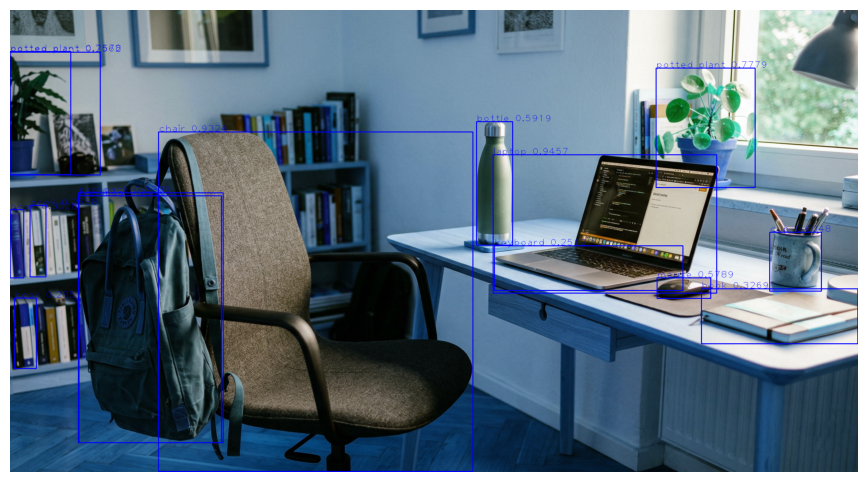

: 

In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

# 모델 불러오기
model = YOLO("yolov8n.pt")

image_path = 'sample.png'
img = cv2.imread(image_path)
result = model.predict(image_path)

for box in result[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().flatten().astype(int)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0, 0, 255), 2)
    cv2.putText(img, f'{result[0].names[int(box.cls)]} {float(box.conf):.4f}', 
                (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0, 0, 255))

# Matplotlib으로 출력
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# cv2.imshow('image', img)
# cv2.waitKey()
# cv2.destroyAllWindows()